# Fashion Clothing Type Classification Baseline

## 1. Objective

The objective of this notebook is to build and evaluate a baseline image classification model that predicts the clothing type of individual fashion items.

The project focuses on four clothing types:

- jacket
- pants
- shoes
- tshirt

This notebook approaches the task as a single-label multiclass classification problem, where each image belongs to exactly one clothing type class.

The purpose of this baseline is to test whether clothing type can be learned reliably from the manually curated dataset. This is an important step for the broader recommendation system, because clothing type can later be combined with predicted style to retrieve compatible outfit items.

## 2. Project Context

In the previous baseline experiment, the project focused on predicting the style of individual clothing items. That experiment showed that style classification is feasible and that the dataset contains useful visual patterns.

However, style alone is not enough to support outfit recommendation. A recommendation system also needs to understand what kind of item is being analyzed. For example, if the input item is a jacket, the system should recommend a different type of item, such as pants or shoes, rather than another jacket.

Because of this, the next step in the project is to predict clothing type. This is a more structured classification problem than style recognition, because clothing types usually have clearer visual boundaries.

The assumption behind this approach is that combining clothing type prediction with style prediction will provide a stronger foundation for a later recommendation system. If a model can predict both what an item is and what style it belongs to, these outputs can be used together to retrieve items that are both stylistically compatible and functionally complementary.

## 3. Dataset Design and Collection Approach

The dataset used in this notebook is the same manually curated fashion dataset used in the previous baseline experiment. The images were collected from online fashion sources and organized according to a custom labeling scheme designed for this project.

The dataset was structured around two dimensions:

- style
- clothing type

The four clothing types used in this notebook are:

- jacket
- pants
- shoes
- tshirt

The four style classes still exist in the dataset as additional metadata:

- formal
- gothic
- sporty
- streetwear

Although both style and clothing type are available, this notebook uses only the clothing type labels as prediction targets. Style remains useful as supporting metadata and will be used again in later stages of the project.

The final type-classification split contains:

- 560 training images
- 120 validation images
- 120 test images
- **800 images in total**

This produces a balanced dataset for the four clothing type classes and allows the baseline model to be evaluated more reliably.

## 4. Label Definitions and Dataset Rules

Because the dataset was manually curated, labeling rules were defined before model training in order to keep the classes as consistent as possible.

A detailed version of these rules is stored in the project repository under:

`dataset/metadata/dataset_rules.md`

This file contains the full style definitions, clothing type definitions, and dataset assignment rules used during data collection and organization.

In this notebook, the target labels are the four clothing types:

- jacket
- pants
- shoes
- tshirt

Each image was assigned to one clothing type only, and ambiguous items were avoided whenever possible during collection.

## 5. Folder Structure, Metadata, and Training Split

The dataset was organized in multiple stages in order to keep the workflow structured and reproducible.

### 5.1. Dataset Organization

The project dataset is stored in a dedicated `dataset` folder in the repository. The main dataset stages are:

- `raw/` for the initially collected images
- `cleaned/` for the reviewed dataset used for experiments
- `metadata/` for supporting files such as labeling rules and image metadata
- `split_type/` for the final train, validation, and test split used in this clothing type baseline

The cleaned dataset preserves both style and clothing type information. For this notebook, the images were reorganized into a type-only classification structure.

### 5.2. Metadata

A metadata file named `labels.csv` was generated automatically from the cleaned folder structure. This file stores, for each image:

- filename
- style
- type

Although this notebook predicts only clothing type, the metadata remains useful for documentation and future recommendation experiments.

### 5.3. Type-Only Training Split

For this baseline, the dataset was converted into a type-only split. Images from all styles belonging to the same clothing type were grouped together into one class folder. This created a standard image-classification structure with separate training, validation, and test folders for the four clothing type classes.

The final split used in this notebook contains:

- **Train**: 140 images per type
- **Validation**: 30 images per type
- **Test**: 30 images per type

This results in a balanced clothing type classification dataset with four classes:

- jacket
- pants
- shoes
- tshirt

## 6. Import Libraries

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

torch version: 2.11.0+cu130
cuda available: True
cuda device count: 1
gpu name: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: CUDA


## 7. Dataset Paths and Image Transforms

The dataset used in this notebook is loaded from the `split_type` directory, which contains separate training, validation, and test folders for the four clothing type classes.

Before training, the images are resized and transformed into tensors. Since the dataset is still relatively modest in size, simple preprocessing is used together with light augmentation for the training set only. This helps the model generalize slightly better without changing the class labels.

In [4]:
# Dataset paths
train_dir = "../dataset/split_type/train"
val_dir = "../dataset/split_type/val"
test_dir = "../dataset/split_type/test"

# Image transforms
train_transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.RandomHorizontalFlip(p=0.5),
  transforms.ToTensor(),
  transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
  )
])

eval_transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor(),
  transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
  )
])

## 8. Load the Dataset

The training, validation, and test datasets are loaded using `ImageFolder`, which automatically assigns class labels based on the folder names.

Data loaders are then created to make it easier to iterate through the dataset in mini-batches during training and evaluation.

In [5]:
# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

# Create dataloaders
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Class names
class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Classes: ['jacket', 'pants', 'shoes', 'tshirt']
Number of classes: 4
Training images: 560
Validation images: 120
Test images: 120


## 9. Dataset Overview and Sample Images

Before training the model, it is useful to inspect the dataset structure and visualize a few sample images.

This helps confirm that:

- the four clothing type classes were loaded correctly
- the dataset split is balanced
- the images appear as expected after preprocessing

### 9.1. Split Summary

In [6]:
split_summary = pd.DataFrame({
  "Split": ["Train", "Validation", "Test"],
  "Images": [len(train_dataset), len(val_dataset), len(test_dataset)]
})

split_summary

,Split,Images
0,Train,560
1,Validation,120
2,Test,120


### 9.2. Class Distribution

In [7]:
def count_images_per_class(dataset):
    counts = {class_name: 0 for class_name in dataset.classes}
    for _, label in dataset.samples:
        class_name = dataset.classes[label]
        counts[class_name] += 1
    return counts

train_counts = count_images_per_class(train_dataset)
val_counts = count_images_per_class(val_dataset)
test_counts = count_images_per_class(test_dataset)

class_distribution = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
})

class_distribution

,Train,Validation,Test
jacket,140,30,30
pants,140,30,30
shoes,140,30,30
tshirt,140,30,30


### 9.3. Sample Images

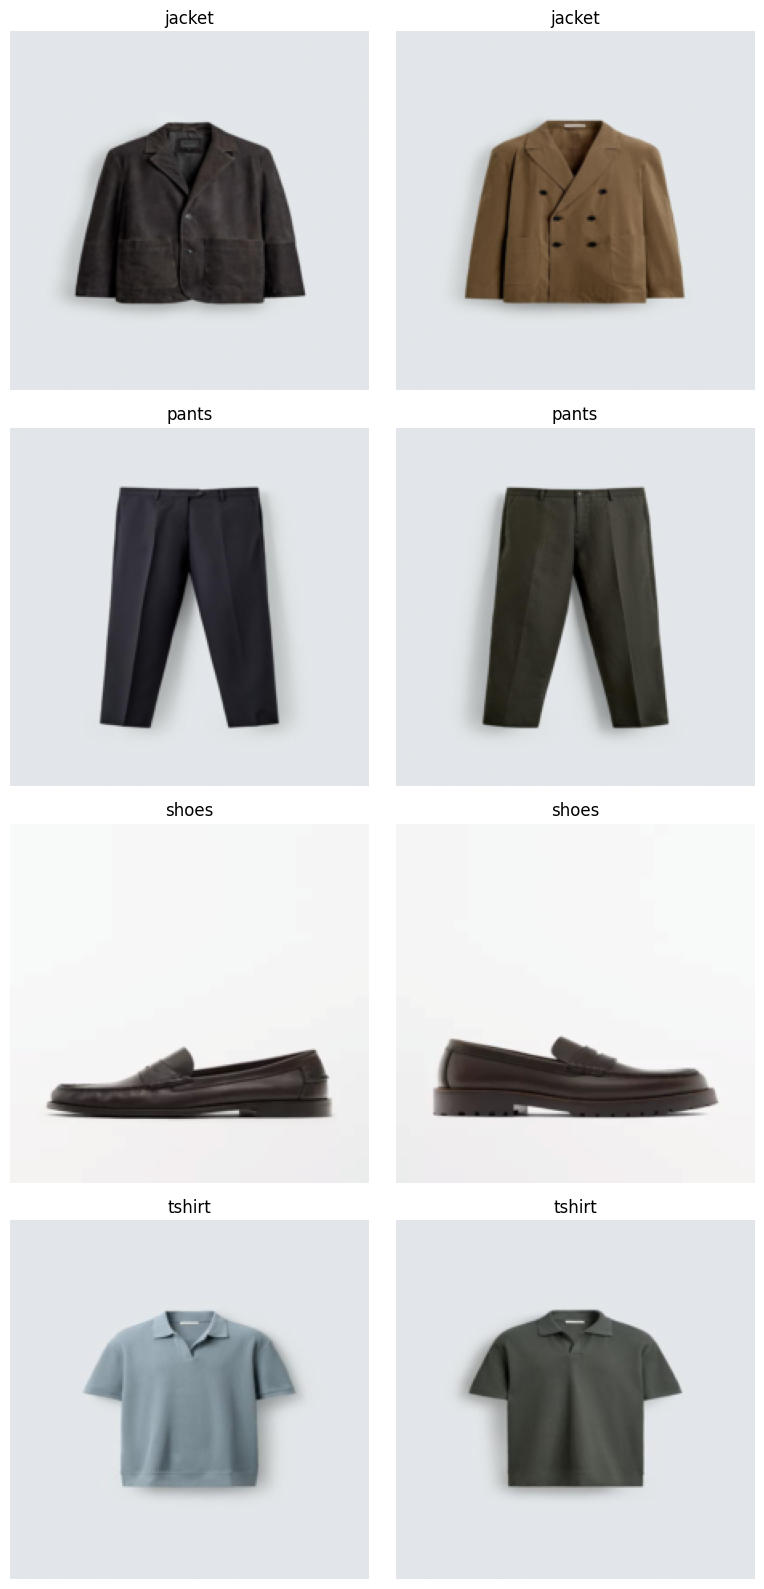

In [8]:
def show_images_per_class(dataset, class_names, images_per_class=2):
    fig, axes = plt.subplots(len(class_names), images_per_class, figsize=(4 * images_per_class, 4 * len(class_names)))

    if len(class_names) == 1:
        axes = np.expand_dims(axes, axis=0)

    class_indices = {i: [] for i in range(len(class_names))}

    for idx, (_, label) in enumerate(dataset.samples):
        if len(class_indices[label]) < images_per_class:
            class_indices[label].append(idx)

        if all(len(indices) == images_per_class for indices in class_indices.values()):
            break

    for class_idx, indices in class_indices.items():
        for j, sample_idx in enumerate(indices):
            image, label = dataset[sample_idx]

            image = image.permute(1, 2, 0).numpy()
            image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            image = np.clip(image, 0, 1)

            axes[class_idx, j].imshow(image)
            axes[class_idx, j].set_title(class_names[label])
            axes[class_idx, j].axis("off")

    plt.tight_layout()
    plt.show()

show_images_per_class(train_dataset, class_names)

## 10. Baseline Model Selection

At the current stage of the project, the dataset is still modest in size for deep learning, even though it is larger than the earliest version of the project. Because of this, training a deep convolutional neural network from scratch would not be the most practical choice for this experiment. Instead, transfer learning is used.

A pretrained `ResNet34` model is selected as the baseline. ResNet34 is a widely used convolutional neural network architecture that has already learned general visual features from the ImageNet dataset. By reusing these learned representations and replacing the final classification layer, the model can be adapted to the four clothing type classes in this project:

- jacket
- pants
- shoes
- tshirt

ResNet34 is used here as a strong and efficient starting point. Using the same architecture as the style-classification baseline also makes it easier to compare the two tasks later.

In [9]:
# Load pretrained ResNet34
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# Replace the final classification layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Move model to device
model = model.to(device)

## 11. Training Configuration

For this baseline experiment, the pretrained feature extractor is frozen and only the final classification layer is trained. This keeps the training process simple and reduces the risk of overfitting on the current dataset.

The model is trained using:

- `CrossEntropyLoss` as the loss function
- `Adam` as the optimizer
- `10 epochs` for the initial experiment

This setup is intended to provide a stable first benchmark rather than a fully optimized final model.

In [10]:
# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the final classification layer
for param in model.fc.parameters():
    param.requires_grad = True

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Training settings
num_epochs = 10

print("Training only the final classification layer.")
print("Number of epochs:", num_epochs)

Training only the final classification layer.
Number of epochs: 10


## 12. Training and Validation Loop

The model is trained for a fixed number of epochs using the training set, while performance on the validation set is monitored after each epoch.

Tracking both training and validation metrics is useful because it helps assess whether the model is learning meaningful patterns and whether it starts to overfit during the baseline experiment.

In [11]:
# Lists to store training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # ----- Training -----
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ----- Validation -----
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
    )

Epoch [1/10] | Train Loss: 1.1335 | Train Acc: 0.5321 | Val Loss: 0.6172 | Val Acc: 0.8917
Epoch [2/10] | Train Loss: 0.5074 | Train Acc: 0.8964 | Val Loss: 0.3215 | Val Acc: 0.9667
Epoch [3/10] | Train Loss: 0.3452 | Train Acc: 0.9232 | Val Loss: 0.2462 | Val Acc: 0.9667
Epoch [4/10] | Train Loss: 0.2768 | Train Acc: 0.9429 | Val Loss: 0.1741 | Val Acc: 0.9667
Epoch [5/10] | Train Loss: 0.2269 | Train Acc: 0.9500 | Val Loss: 0.1530 | Val Acc: 0.9583
Epoch [6/10] | Train Loss: 0.1772 | Train Acc: 0.9607 | Val Loss: 0.1297 | Val Acc: 0.9750
Epoch [7/10] | Train Loss: 0.1600 | Train Acc: 0.9714 | Val Loss: 0.1001 | Val Acc: 0.9833
Epoch [8/10] | Train Loss: 0.1518 | Train Acc: 0.9661 | Val Loss: 0.0881 | Val Acc: 0.9917
Epoch [9/10] | Train Loss: 0.1344 | Train Acc: 0.9643 | Val Loss: 0.0784 | Val Acc: 0.9917
Epoch [10/10] | Train Loss: 0.1172 | Train Acc: 0.9768 | Val Loss: 0.0690 | Val Acc: 1.0000


## 13. Training History

After training, the recorded loss and accuracy values can be visualized to better understand how the model behaved across epochs.

The training and validation curves help indicate whether the model is learning meaningful patterns and whether signs of overfitting appear during the baseline experiment.

### 13.1. Loss plot

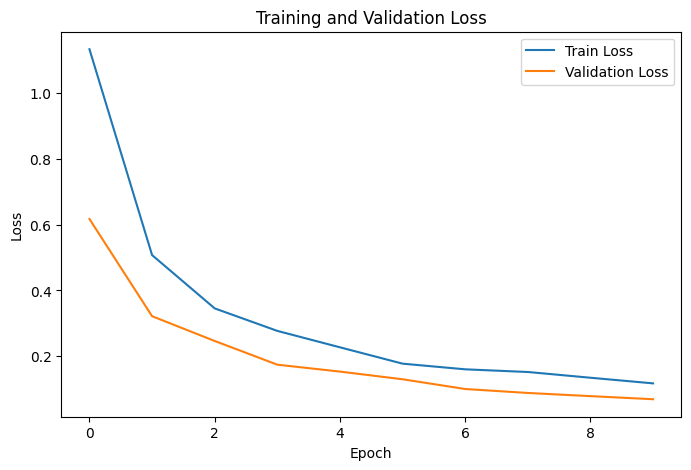

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 13.2. Accuracy plot

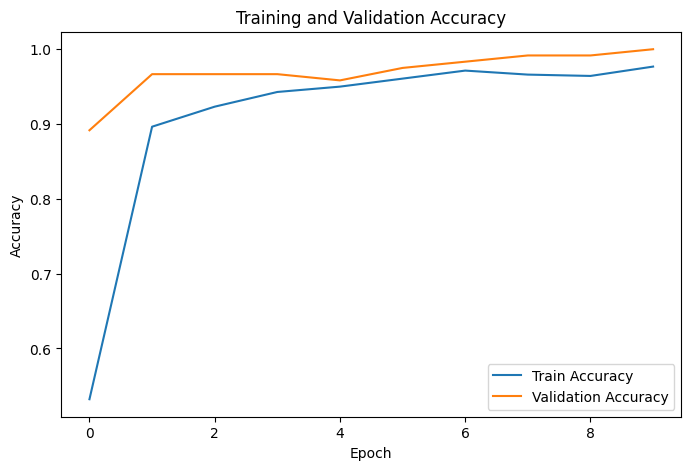

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 14. Test Set Evaluation

After training and validation, the final model is evaluated on the test set. This provides a clearer estimate of how well the baseline model generalizes to unseen fashion images.

The evaluation includes:

- test accuracy
- classification report
- confusion matrix

These results help identify not only the overall performance of the baseline, but also which clothing type classes are easier or harder to distinguish.

### 14.1. Predictions and test accuracy

In [14]:
# Evaluate on the test set
model.eval()

all_preds = []
all_labels = []

correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

test_accuracy = correct_test / total_test
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 1.0000


### 14.2. Classification report

In [15]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

      jacket       1.00      1.00      1.00        30
       pants       1.00      1.00      1.00        30
       shoes       1.00      1.00      1.00        30
      tshirt       1.00      1.00      1.00        30

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



### 14.3. Confusion matrix

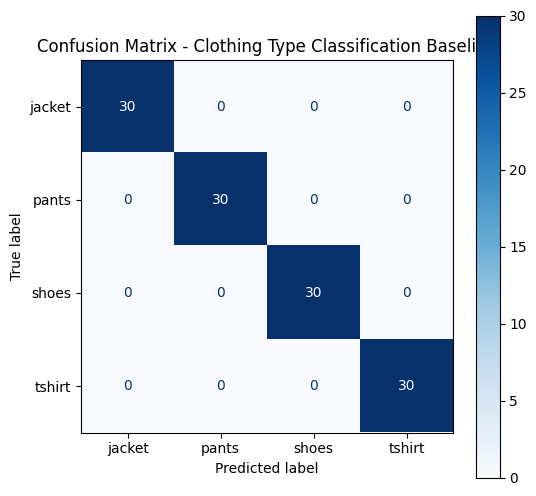

In [16]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Clothing Type Classification Baseline")
plt.show()

## 14.4. External Test Set Evaluation

The internal test set produced a perfect accuracy score, which is useful but should be interpreted carefully. Since the dataset is manually curated and visually consistent, the internal test split may be easier than a real-world use case.

To better evaluate generalization, a small external test set was created manually. This external set contains 20 new images that were not used in the original dataset:

- 5 jacket images
- 5 pants images
- 5 shoes images
- 5 tshirt images

The goal of this additional test is to check whether the model can still recognize clothing types when the images come from outside the original dataset.

In [17]:
external_dir = "../dataset/external_type_test"

external_dataset = datasets.ImageFolder(external_dir, transform=eval_transform)
external_loader = DataLoader(external_dataset, batch_size=16, shuffle=False)

external_class_names = external_dataset.classes

print("External classes:", external_class_names)
print("External images:", len(external_dataset))

External classes: ['jacket', 'pants', 'shoes', 'tshirt']
External images: 20


### 14.4.1. Predictions and test accuracy

In [18]:
model.eval()

all_ext_preds = []
all_ext_labels = []

correct_ext = 0
total_ext = 0

with torch.no_grad():
    for images, labels in external_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_ext_preds.extend(preds.cpu().numpy())
        all_ext_labels.extend(labels.cpu().numpy())

        correct_ext += (preds == labels).sum().item()
        total_ext += labels.size(0)

external_accuracy = correct_ext / total_ext
print(f"External Test Accuracy: {external_accuracy:.4f}")

External Test Accuracy: 0.9000


### 14.4.2. Classification report

In [19]:
print(classification_report(all_ext_labels, all_ext_preds, target_names=external_class_names))

              precision    recall  f1-score   support

      jacket       0.83      1.00      0.91         5
       pants       0.80      0.80      0.80         5
       shoes       1.00      1.00      1.00         5
      tshirt       1.00      0.80      0.89         5

    accuracy                           0.90        20
   macro avg       0.91      0.90      0.90        20
weighted avg       0.91      0.90      0.90        20



### 14.4.3. Confusion matrix

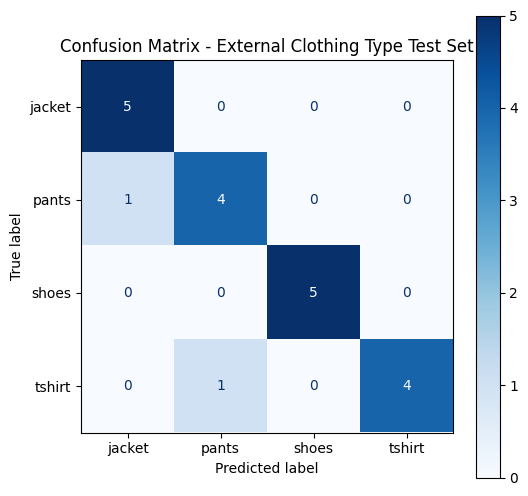

In [20]:
cm_ext = confusion_matrix(all_ext_labels, all_ext_preds)
disp_ext = ConfusionMatrixDisplay(confusion_matrix=cm_ext, display_labels=external_class_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp_ext.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - External Clothing Type Test Set")
plt.show()

## 14.5. Results Interpretation

The model achieved a test accuracy of **1.00** on the internal test split, with perfect precision, recall, and F1-scores for all four clothing type classes. At first, this result appears unusually strong, especially for a first baseline experiment.

However, the training curves do not show classic overfitting. Both training and validation loss decreased during training, and validation accuracy improved steadily. This suggests that the model did learn useful visual patterns rather than simply failing to generalize during training.

A likely explanation is that clothing type classification is much easier than style classification in this dataset. Clothing types such as jackets, pants, shoes, and tshirts have clearer structural differences than fashion styles. The dataset is also highly curated, with mostly clean product-style images, clear item visibility, and limited background noise. This makes the internal test split relatively easy for the model.

To test this further, an external test set of 20 new images was created. On this external set, the model achieved an accuracy of **0.90** and a macro F1-score of **0.90**. This confirms that the model learned meaningful clothing type features, because it still performed well on images outside the original dataset.

At the same time, the drop from **1.00** on the internal test set to **0.90** on the external test set shows that the internal split was easier and more controlled. The external mistakes were also reasonable: one pants image was predicted as jacket, and one tshirt image was predicted as pants. These errors likely happened because the external images contained more varied poses, presentation styles, or extra visual context.

Overall, the results show that clothing type classification is highly feasible and useful for the recommendation system. However, the perfect internal score should not be treated as proof of full real-world generalization.

## 15. Limitations

This baseline has several limitations.

First, the internal dataset is highly curated and visually consistent. Most images contain a single dominant clothing item, clear visibility, and relatively simple backgrounds. This makes the classification task easier than real-world fashion images.

Second, the internal test split produced perfect performance, but the external evaluation showed a drop from **1.00** to **0.90** accuracy. This suggests that the model generalizes reasonably well, but also benefits from the controlled nature of the original dataset.

Third, clothing type is easier to classify than style because the selected categories have clearer structural differences. Strong performance in this notebook should therefore not be interpreted as evidence that more subjective tasks, such as style recognition or outfit compatibility, are equally easy.

Fourth, the model uses a frozen pretrained feature extractor and only trains the final classification layer. This makes the experiment efficient and stable, but it may limit performance on more diverse or challenging datasets.

Finally, the external test set is still small, with only 20 images in total. It provides a useful sanity check, but it is not large enough to act as a final benchmark.

## 16. Conclusion

This notebook presented the second baseline experiment for the fashion recommendation project by focusing on clothing type classification as a single-label multiclass image classification task.

Using a manually curated dataset of **800** clothing images, a pretrained `ResNet34` model was trained to classify four clothing types: jacket, pants, shoes, and tshirt. On the internal test split, the model achieved a perfect accuracy of **1.00**.

Because this result appeared unusually strong, an additional external evaluation was performed using 20 new images collected outside the original dataset. On this external test set, the model achieved an accuracy of **0.90** and a macro F1-score of **0.90**.

These results show that the model learned meaningful clothing type features and can generalize beyond the original split, although performance decreases when the images are more varied and less controlled.

Overall, clothing type classification is a strong and reliable component for the future recommendation system. Together with the previously developed style classifier, it provides the foundation for retrieving compatible outfit items based on both predicted style and predicted clothing type.

## 17. Next Steps

The next stage of the project will focus on combining the style classifier and clothing type classifier into a simple recommendation prototype.

The most important next steps are:

- compare the style classification and clothing type classification baselines
- document why clothing type classification performed better than style classification
- build a simple recommendation system using predicted style and predicted clothing type
- retrieve items with the same predicted style but a different clothing type
- visualize recommendation examples using input images and suggested outfit items
- expand the dataset further to include more varied and realistic images

In this way, this notebook completes the second technical baseline and prepares the project for the first recommendation prototype.

## 18. Exporting model

In [21]:
os.makedirs("../models", exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names
}, "../models/type_resnet34.pth")

print("Type model saved.")

Type model saved.
